# Gap Parameter Fitting — Eq. C1 Method

This notebook fits a parametric brightness temperature model (Eq. C1 from the paper appendix) to **frank radial profiles** of each disk, in order to measure the center, width, and depth of each gap of interest.

The resulting parameters (`rgap`, `σgap`, `δgap`, `T0`, `q`) are then used to define the injection zone in the injection-recovery pipeline (`HPC_eqC1_gap/`).

## The Model — Equation C1

The brightness temperature profile is modelled as a **local power-law background with a Gaussian depletion**:

$$T_b(r) = T_0 \left(\frac{r}{0.1''}\right)^{-q} \cdot \frac{1}{1 + \Gamma}$$

where the depletion term is:

$$\Gamma(r) = (\delta_\mathrm{gap} - 1) \cdot \exp\!\left[-\frac{(r - r_\mathrm{gap})^2}{2\,\sigma_\mathrm{gap}^2}\right]$$

### Parameters

All 5 parameters are **free parameters fitted from the frank radial profile** — you do not need to know any of them beforehand. You only need to provide:
- The frank radial profile (the data)
- A radial range `[r_min, r_max]` that brackets the gap on both sides
- Rough initial guesses (read off by eye from the profile plot)

| Parameter | Symbol | What it describes | How to guess |
|---|---|---|---|
| Background normalisation | $T_0$ | T_b value at r = 0.1" on the local power-law (K) | Read T_b near the gap from the frank plot |
| Power-law index | $q$ | How steeply the background falls with radius | Start with q ≈ 1–3; steeper disk → higher q |
| Gap centre | $r_\mathrm{gap}$ | Radial location of the gap minimum (arcsec) | Read off from the frank profile dip |
| Gap width | $\sigma_\mathrm{gap}$ | Gaussian std dev of the gap (arcsec) | Roughly half the visible gap width |
| Gap depth | $\delta_\mathrm{gap}$ | Multiplicative depletion at $r_\mathrm{gap}$ | Ratio of background to gap floor; start with 2–10 |

**Note on δgap**: multiplicative scale, not fractional depth.
- δgap = 1 → no gap (Γ = 0)
- δgap = 2 → brightness halved at gap centre
- δgap = 10 → order-of-magnitude depletion at gap centre

**Note on T0, q**: describe the *local* background near the gap only — fit a narrow radial window, not the entire disk.

## Workflow

1. Load the **frank radial profile** for the disk (T_b vs r in arcsec)
2. Isolate the radial range around the gap of interest
3. Fit Eq. C1 to that sub-profile using `scipy.optimize.curve_fit`
4. Visually inspect the fit — adjust initial guesses if needed
5. Record the fitted parameters in `diskdictionary_eqC1.py`

### What the frank visibility comparison is (not needed here)

The paper (Figure 14) also shows deprojected, azimuthally averaged visibilities vs the frank model as a **quality check that frank converged correctly** in the UV/Fourier domain. This is already done when you ran frank — you do not need to redo it here. The Eq. C1 fitting is done entirely on the frank output radial profile in image space.

## Adopted Parameters Table

To be filled in as fits are completed. Mirrors Table 3 in the paper.

| Disk | Gap | $T_0$ (K) | $q$ | $r_\mathrm{gap}$ (") | $\sigma_\mathrm{gap}$ (") | $\delta_\mathrm{gap}$ |
|---|---|---|---|---|---|---|
| J1852 | 0 | | | | | |
| AA_Tau | 0 | | | | | |
| AA_Tau | 1 | | | | | |
| CQ_Tau | 0 | | | | | |
| DM_Tau | 0 | | | | | |
| DM_Tau | 1 | | | | | |
| HD_135344B | 0 | | | | | |
| HD_135344B | 1 | | | | | |
| HD_143006 | 0 | | | | | |
| HD_34282 | 0 | | | | | |
| J1604 | 0 | | | | | |
| J1615 | 0 | | | | | |
| J1615 | 1 | | | | | |
| J1842 | 0 | | | | | |
| LkCa_15 | 0 | | | | | |
| LkCa_15 | 1 | | | | | |
| MWC_758 | 0 | | | | | |
| MWC_758 | 1 | | | | | |
| SY_Cha | 0 | | | | | |

---
## Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [3]:
# ── Load gap_clicks.csv — manual click estimates per disk/gap ────────────────
clicks = pd.read_csv(r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_clicks.csv')

def get_gap_guesses(disk, gap_ix):
    """Return (r_min, r_max, r_gap_guess, sigma_gap_guess) from gap_clicks.
    
    r_min  = inner_edge - 0.05"  (a little inside, to catch background)
    r_max  = ring_peak  + 0.05"  (a little outside, to catch background)
    r_gap  = gap_dip             (the clicked gap minimum)
    sigma  = (outer_edge - inner_edge) / 2  (rough half-width)
    """
    d = clicks[clicks['disk'] == disk].copy()
    # each gap is a group of 4 rows (dip, ring_peak, inner_edge, outer_edge)
    # gap_ix=0 → first group, gap_ix=1 → second group
    dips        = d[d['label'] == 'gap_dip'      ].reset_index(drop=True)
    rings       = d[d['label'] == 'ring_peak'    ].reset_index(drop=True)
    inner_edges = d[d['label'] == 'inner_edge'   ].reset_index(drop=True)
    outer_edges = d[d['label'] == 'outer_edge'   ].reset_index(drop=True)

    if gap_ix >= len(dips):
        raise ValueError(f'gap_ix={gap_ix} not found for {disk} in gap_clicks.csv')

    r_dip   = dips.loc[gap_ix,   'r_arcsec']
    r_ring  = rings.loc[gap_ix,  'r_arcsec']
    r_inner = inner_edges.loc[gap_ix, 'r_arcsec']
    r_outer = outer_edges.loc[gap_ix, 'r_arcsec']

    r_min        = max(r_inner - 0.05, 0.01)
    r_max        = r_ring  + 0.05
    r_gap_guess  = r_dip
    sigma_guess  = (r_outer - r_inner) / 2

    print(f'{disk} gap{gap_ix}:')
    print(f'  gap_dip    = {r_dip:.3f}"   → r_gap  initial guess')
    print(f'  inner_edge = {r_inner:.3f}"  |  outer_edge = {r_outer:.3f}"')
    print(f'  ring_peak  = {r_ring:.3f}"')
    print(f'  fit range  = [{r_min:.3f}", {r_max:.3f}"]')
    print(f'  sigma_gap  ≈ {sigma_guess:.3f}"')

    return r_min, r_max, r_gap_guess, sigma_guess

# preview all available disks/gaps in gap_clicks
print('Disks in gap_clicks:')
print(clicks[clicks['label']=='gap_dip'][['disk','r_arcsec']].to_string(index=False))

Disks in gap_clicks:
      disk  r_arcsec
    DM_Tau      0.07
HD_135344B      0.51
HD_135344B      0.11
     J1604      0.37
     J1615      0.55
     J1615      0.05
     J1852      0.19
   LkCa_15      0.57
   LkCa_15      0.07
   MWC_758      0.13
   MWC_758      0.41
    SY_Cha      0.19
 V4046_Sgr      0.09
 V4046_Sgr      0.27
    AA_Tau      0.13
    AA_Tau      0.57
    CQ_Tau      0.05


In [4]:
def eqC1(r, I0, q, r_gap, sigma_gap, delta_gap):
    """Eq. C1 intensity profile model (fitted to CLEAN profile in mJy/beam).

    Parameters
    ----------
    r          : radial distance in arcsec
    I0         : background normalisation at r=0.1" (mJy/beam)
    q          : power-law index of background
    r_gap      : gap centre (arcsec)
    sigma_gap  : gap Gaussian width (arcsec)
    delta_gap  : gap depletion factor (multiplicative; delta=1 → no gap)
    """
    background = I0 * (r / 0.1)**(-q)
    Gamma = (delta_gap - 1) * np.exp(-0.5 * ((r - r_gap) / sigma_gap)**2)
    return background / (1 + Gamma)

CQ_Tau gap0:
  gap_dip    = 0.050"   → r_gap  initial guess
  inner_edge = 0.010"  |  outer_edge = 0.090"
  ring_peak  = 0.090"
  fit range  = [0.010", 0.140"]
  sigma_gap  ≈ 0.040"
  fit range: [0.005", 0.240"]  (inner +0.02", outer +0.1")
  15 data points in fit range


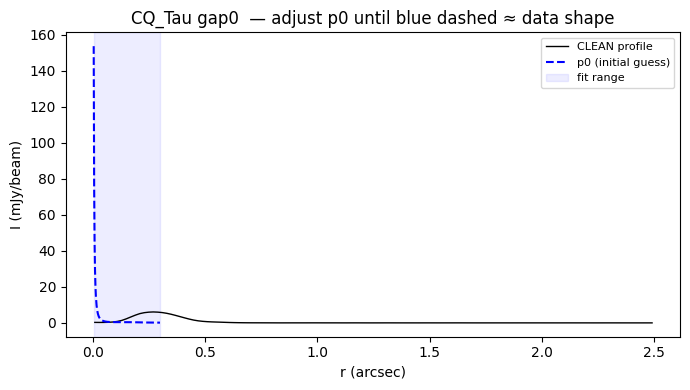


Fitted parameters:
  I0     = 5.945 ± 1.264 mJy/beam
  q      = 0.00  ± 0.21
  r_gap  = 0.0400 ± 0.0250 "
  s_gap  = 0.0550 ± 0.0078 "
  d_gap  = 15.23  ± 7.51


In [5]:
# ── USER INPUT ──────────────────────────────────────────────────────────────
target  = 'CQ_Tau'
gap_ix  = 0

# Asymmetric fit-range margins (arcsec beyond the click-derived edges).
# inner: keep small — the inner disk rises steeply and breaks the power-law.
# outer: can be larger to capture more background ring for q, I0 pinning.
fit_margin_inner = 0.02   # arcsec added to the left of inner_edge
fit_margin_outer = 0.10   # arcsec added to the right of ring_peak

# get r_min, r_max, r_gap and sigma_gap from gap_clicks (rough initial guesses)
r_min_base, r_max_base, r_gap_guess, sigma_guess = get_gap_guesses(target, gap_ix)

# expand the fit range asymmetrically
r_min = max(r_min_base - fit_margin_inner, 0.005)
r_max = r_max_base + fit_margin_outer
print(f'  fit range: [{r_min:.3f}", {r_max:.3f}"]  '
      f'(inner +{fit_margin_inner}", outer +{fit_margin_outer}")')

# ── initial guesses ───────────────────────────────────────────────────────────
# I0:    intensity at r=0.1" on the local power-law (mJy/beam)
#        → read off the CLEAN profile near the gap; try 0.5–10 mJy/beam
# q:     power-law slope (~1–3; steeper disk → larger q)
# delta: gap depth ratio (>1; 2 = brightness halved; start with 2–10)


#manual fix:
#r_gap_guess = 0.58
#r_min = 0.38
r_max = 0.3


p0 = [1.2,  2.0,  r_gap_guess,  sigma_guess,  5.0]
#      I0    q      r_gap          sigma         delta

# ────────────────────────────────────────────────────────────────────────────

# ── load CLEAN profile (robust = -0.5) ───────────────────────────────────────
clean_file = rf'D:\exoALMA_disk_data\{target}\{target}_CLEAN_profile_robust-05.txt'
dat = np.loadtxt(clean_file, comments='#')
r, r_au, I_mJy, dI_mJy = dat[:, 0], dat[:, 1], dat[:, 2], dat[:, 3]

# restrict to fit range
mask = (r >= r_min) & (r <= r_max)
r_fit, I_fit = r[mask], I_mJy[mask]
print(f'  {mask.sum()} data points in fit range')

# ── DIAGNOSTIC: plot p0 before fitting ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r, I_mJy, 'k-', lw=1, label='CLEAN profile')
r_model = np.linspace(r_min, r_max, 300)
ax.plot(r_model, eqC1(r_model, *p0), 'b--', lw=1.5, label='p0 (initial guess)')
ax.axvspan(r_min, r_max, alpha=0.07, color='blue', label='fit range')
ax.set_xlabel('r (arcsec)'); ax.set_ylabel('I (mJy/beam)')
ax.set_title(f'{target} gap{gap_ix}  — adjust p0 until blue dashed ≈ data shape')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# ── FIT ──────────────────────────────────────────────────────────────────────
# bounds: keep r_gap near the click, sigma > 0, delta > 1
# In, q, r_gap, sigma_gap, delta_gap
lo = [0,     0,   r_gap_guess - 0.01,  0.005,  1.01]
hi = [1e4,  10,   r_gap_guess + 0.01,  0.3,    200.]

popt, pcov = curve_fit(
    eqC1, r_fit, I_fit,
    p0=p0,
    bounds=(lo, hi),
    method='trf',      # Trust Region Reflective — handles parameter scale mismatch
    maxfev=50000,
)
I0_fit, q_fit, rgap_fit, sgap_fit, dgap_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f'\nFitted parameters:')
print(f'  I0     = {I0_fit:.3f} ± {perr[0]:.3f} mJy/beam')
print(f'  q      = {q_fit:.2f}  ± {perr[1]:.2f}')
print(f'  r_gap  = {rgap_fit:.4f} ± {perr[2]:.4f} "')
print(f'  s_gap  = {sgap_fit:.4f} ± {perr[3]:.4f} "')
print(f'  d_gap  = {dgap_fit:.2f}  ± {perr[4]:.2f}')

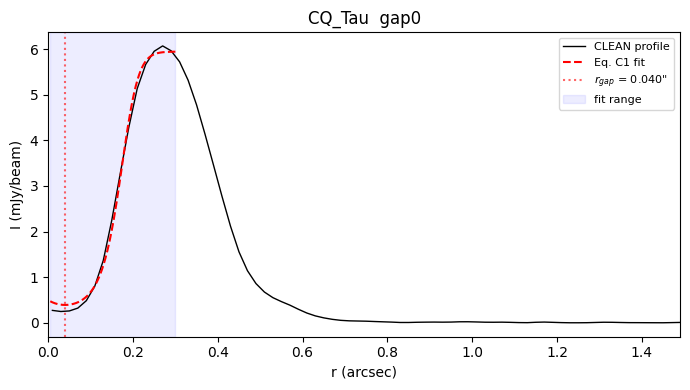

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(r, I_mJy, 'k-', lw=1, label='CLEAN profile')
r_model = np.linspace(r_min, r_max, 500)
ax.plot(r_model, eqC1(r_model, *popt), 'r--', lw=1.5, label='Eq. C1 fit')
ax.axvline(rgap_fit, color='r', ls=':', alpha=0.6, label=f'$r_{{gap}}$ = {rgap_fit:.3f}"')
ax.axvspan(r_min, r_max, alpha=0.07, color='blue', label='fit range')
ax.set_xlabel('r (arcsec)')
ax.set_ylabel('I (mJy/beam)')
ax.set_title(f'{target}  gap{gap_ix}')
ax.legend(fontsize=8)
ax.set_xlim([0, r[r < 1.5].max()])
plt.tight_layout()
plt.show()

Problem: what should the r range be then? 

In [7]:
# ── Results summary — copy-paste into diskdictionary_eqC1.py ─────────────────
print('=' * 60)
print(f'  {target}  gap{gap_ix}  —  Eq. C1 fit results')
print('=' * 60)
print(f'  I0     = {I0_fit:.4f}  mJy/beam')
print(f'  q      = {q_fit:.4f}')
print(f'  r_gap  = {rgap_fit:.4f}  "')
print(f'  s_gap  = {sgap_fit:.4f}  "')
print(f'  d_gap  = {dgap_fit:.4f}')
print()
print(f'  Uncertainties (1σ):')
print(f'  σ(I0)    = {perr[0]:.4f}  mJy/beam')
print(f'  σ(q)     = {perr[1]:.4f}')
print(f'  σ(r_gap) = {perr[2]:.4f}  "')
print(f'  σ(s_gap) = {perr[3]:.4f}  "')
print(f'  σ(d_gap) = {perr[4]:.4f}')
print()
print('  ── diskdictionary_eqC1.py snippet ──────────────────────')
print(f"  '{target}': {{")
print(f"      'gap{gap_ix}': {{")
print(f"          'rgap':  {rgap_fit:.4f},   # arcsec")
print(f"          'wgap':  {sgap_fit:.4f},   # sigma_gap arcsec  (use 2*sgap for ±2σ zone)")
print(f"          'dgap':  {dgap_fit:.2f},")
print(f"      }},")
print(f"  }},")
print('=' * 60)

  CQ_Tau  gap0  —  Eq. C1 fit results
  I0     = 5.9449  mJy/beam
  q      = 0.0000
  r_gap  = 0.0400  "
  s_gap  = 0.0550  "
  d_gap  = 15.2282

  Uncertainties (1σ):
  σ(I0)    = 1.2639  mJy/beam
  σ(q)     = 0.2145
  σ(r_gap) = 0.0250  "
  σ(s_gap) = 0.0078  "
  σ(d_gap) = 7.5135

  ── diskdictionary_eqC1.py snippet ──────────────────────
  'CQ_Tau': {
      'gap0': {
          'rgap':  0.0400,   # arcsec
          'wgap':  0.0550,   # sigma_gap arcsec  (use 2*sgap for ±2σ zone)
          'dgap':  15.23,
      },
  },


In [8]:
# ── Comparison: manual clicks vs Eq. C1 fit ──────────────────────────────────
import pandas as pd

clicks = pd.read_csv(r'D:\CPD_MPIA\Injection_Recovery_Revised\gap_clicks.csv')
d = clicks[clicks['disk'] == target].reset_index(drop=True)

# pull per-label rows, one entry per gap_ix
dips   = d[d['label'] == 'gap_dip'   ].reset_index(drop=True)
inners = d[d['label'] == 'inner_edge'].reset_index(drop=True)
outers = d[d['label'] == 'outer_edge'].reset_index(drop=True)

r_dip_click   = dips.loc[gap_ix,   'r_arcsec']
r_inner_click = inners.loc[gap_ix, 'r_arcsec']
r_outer_click = outers.loc[gap_ix, 'r_arcsec']
method_click  = dips.loc[gap_ix,   'method']
wgap_click    = (r_outer_click - r_inner_click) / 2

rows = {
    'Parameter': ['r_gap  (")', 'σ_gap / half-width  (")', 'gap full width  (")',
                  'inner edge  (")', 'outer edge  (")'],
    'Manual click': [
        f'{r_dip_click:.4f}',
        f'{wgap_click:.4f}',
        f'{r_outer_click - r_inner_click:.4f}',
        f'{r_inner_click:.4f}',
        f'{r_outer_click:.4f}',
    ],
    'Eq. C1 fit': [
        f'{rgap_fit:.4f}  ± {perr[2]:.4f}',
        f'{sgap_fit:.4f}  ± {perr[3]:.4f}',
        f'{2*sgap_fit:.4f}',
        f'{rgap_fit - sgap_fit:.4f}',
        f'{rgap_fit + sgap_fit:.4f}',
    ],
}

df_cmp = pd.DataFrame(rows)
print(f'\n  {target}  gap{gap_ix}  |  click method: {method_click}')
print(df_cmp.to_string(index=False))
print()
print('  Note: Eq. C1 inner/outer edges = r_gap ± 1σ_gap  (68% depletion zone).')
print('        For the injection zone use r_gap ± 2σ_gap to cover ±2σ.')


  CQ_Tau  gap0  |  click method: beam_0.5fwhm
              Parameter Manual click       Eq. C1 fit
             r_gap  (")       0.0500 0.0400  ± 0.0250
σ_gap / half-width  (")       0.0400 0.0550  ± 0.0078
    gap full width  (")       0.0800           0.1101
        inner edge  (")       0.0100          -0.0150
        outer edge  (")       0.0900           0.0950

  Note: Eq. C1 inner/outer edges = r_gap ± 1σ_gap  (68% depletion zone).
        For the injection zone use r_gap ± 2σ_gap to cover ±2σ.


In [9]:
# ── Save fit results to CSV ───────────────────────────────────────────────────
import os, csv
from datetime import datetime

RESULTS_CSV = r'D:\CPD_MPIA\HPC_eqC1_gap\eqC1_fit_results.csv'

fields = [
    'disk', 'gap_ix',
    # fitted parameters
    'I0_fit', 'I0_err',
    'q_fit',  'q_err',
    'rgap_fit', 'rgap_err',
    'sgap_fit', 'sgap_err',
    'dgap_fit', 'dgap_err',
    # derived from fit
    'inner_edge_fit', 'outer_edge_fit',   # r_gap ± 1σ
    # manual click values
    'r_gap_click', 'r_inner_click', 'r_outer_click', 'click_method',
    # fit settings
    'fit_margin_inner', 'fit_margin_outer', 'r_min', 'r_max',
    'timestamp',
]

row = dict(
    disk=target, gap_ix=gap_ix,
    I0_fit=round(I0_fit, 5),   I0_err=round(perr[0], 5),
    q_fit=round(q_fit, 5),     q_err=round(perr[1], 5),
    rgap_fit=round(rgap_fit, 5), rgap_err=round(perr[2], 5),
    sgap_fit=round(sgap_fit, 5), sgap_err=round(perr[3], 5),
    dgap_fit=round(dgap_fit, 5), dgap_err=round(perr[4], 5),
    inner_edge_fit=round(rgap_fit - sgap_fit, 5),
    outer_edge_fit=round(rgap_fit + sgap_fit, 5),
    r_gap_click=r_dip_click, r_inner_click=r_inner_click,
    r_outer_click=r_outer_click, click_method=method_click,
    fit_margin_inner=fit_margin_inner, fit_margin_outer=fit_margin_outer,
    r_min=round(r_min, 5), r_max=round(r_max, 5),
    timestamp=datetime.now().isoformat(timespec='seconds'),
)

# append (or create with header)
new_file = not os.path.isfile(RESULTS_CSV)
with open(RESULTS_CSV, 'a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=fields)
    if new_file:
        w.writeheader()
    w.writerow(row)

print(f'Saved  →  {RESULTS_CSV}')
print(f'  {target}  gap{gap_ix}:  rgap={rgap_fit:.4f}"  sgap={sgap_fit:.4f}"  dgap={dgap_fit:.2f}')

Saved  →  D:\CPD_MPIA\HPC_eqC1_gap\eqC1_fit_results.csv
  CQ_Tau  gap0:  rgap=0.0400"  sgap=0.0550"  dgap=15.23


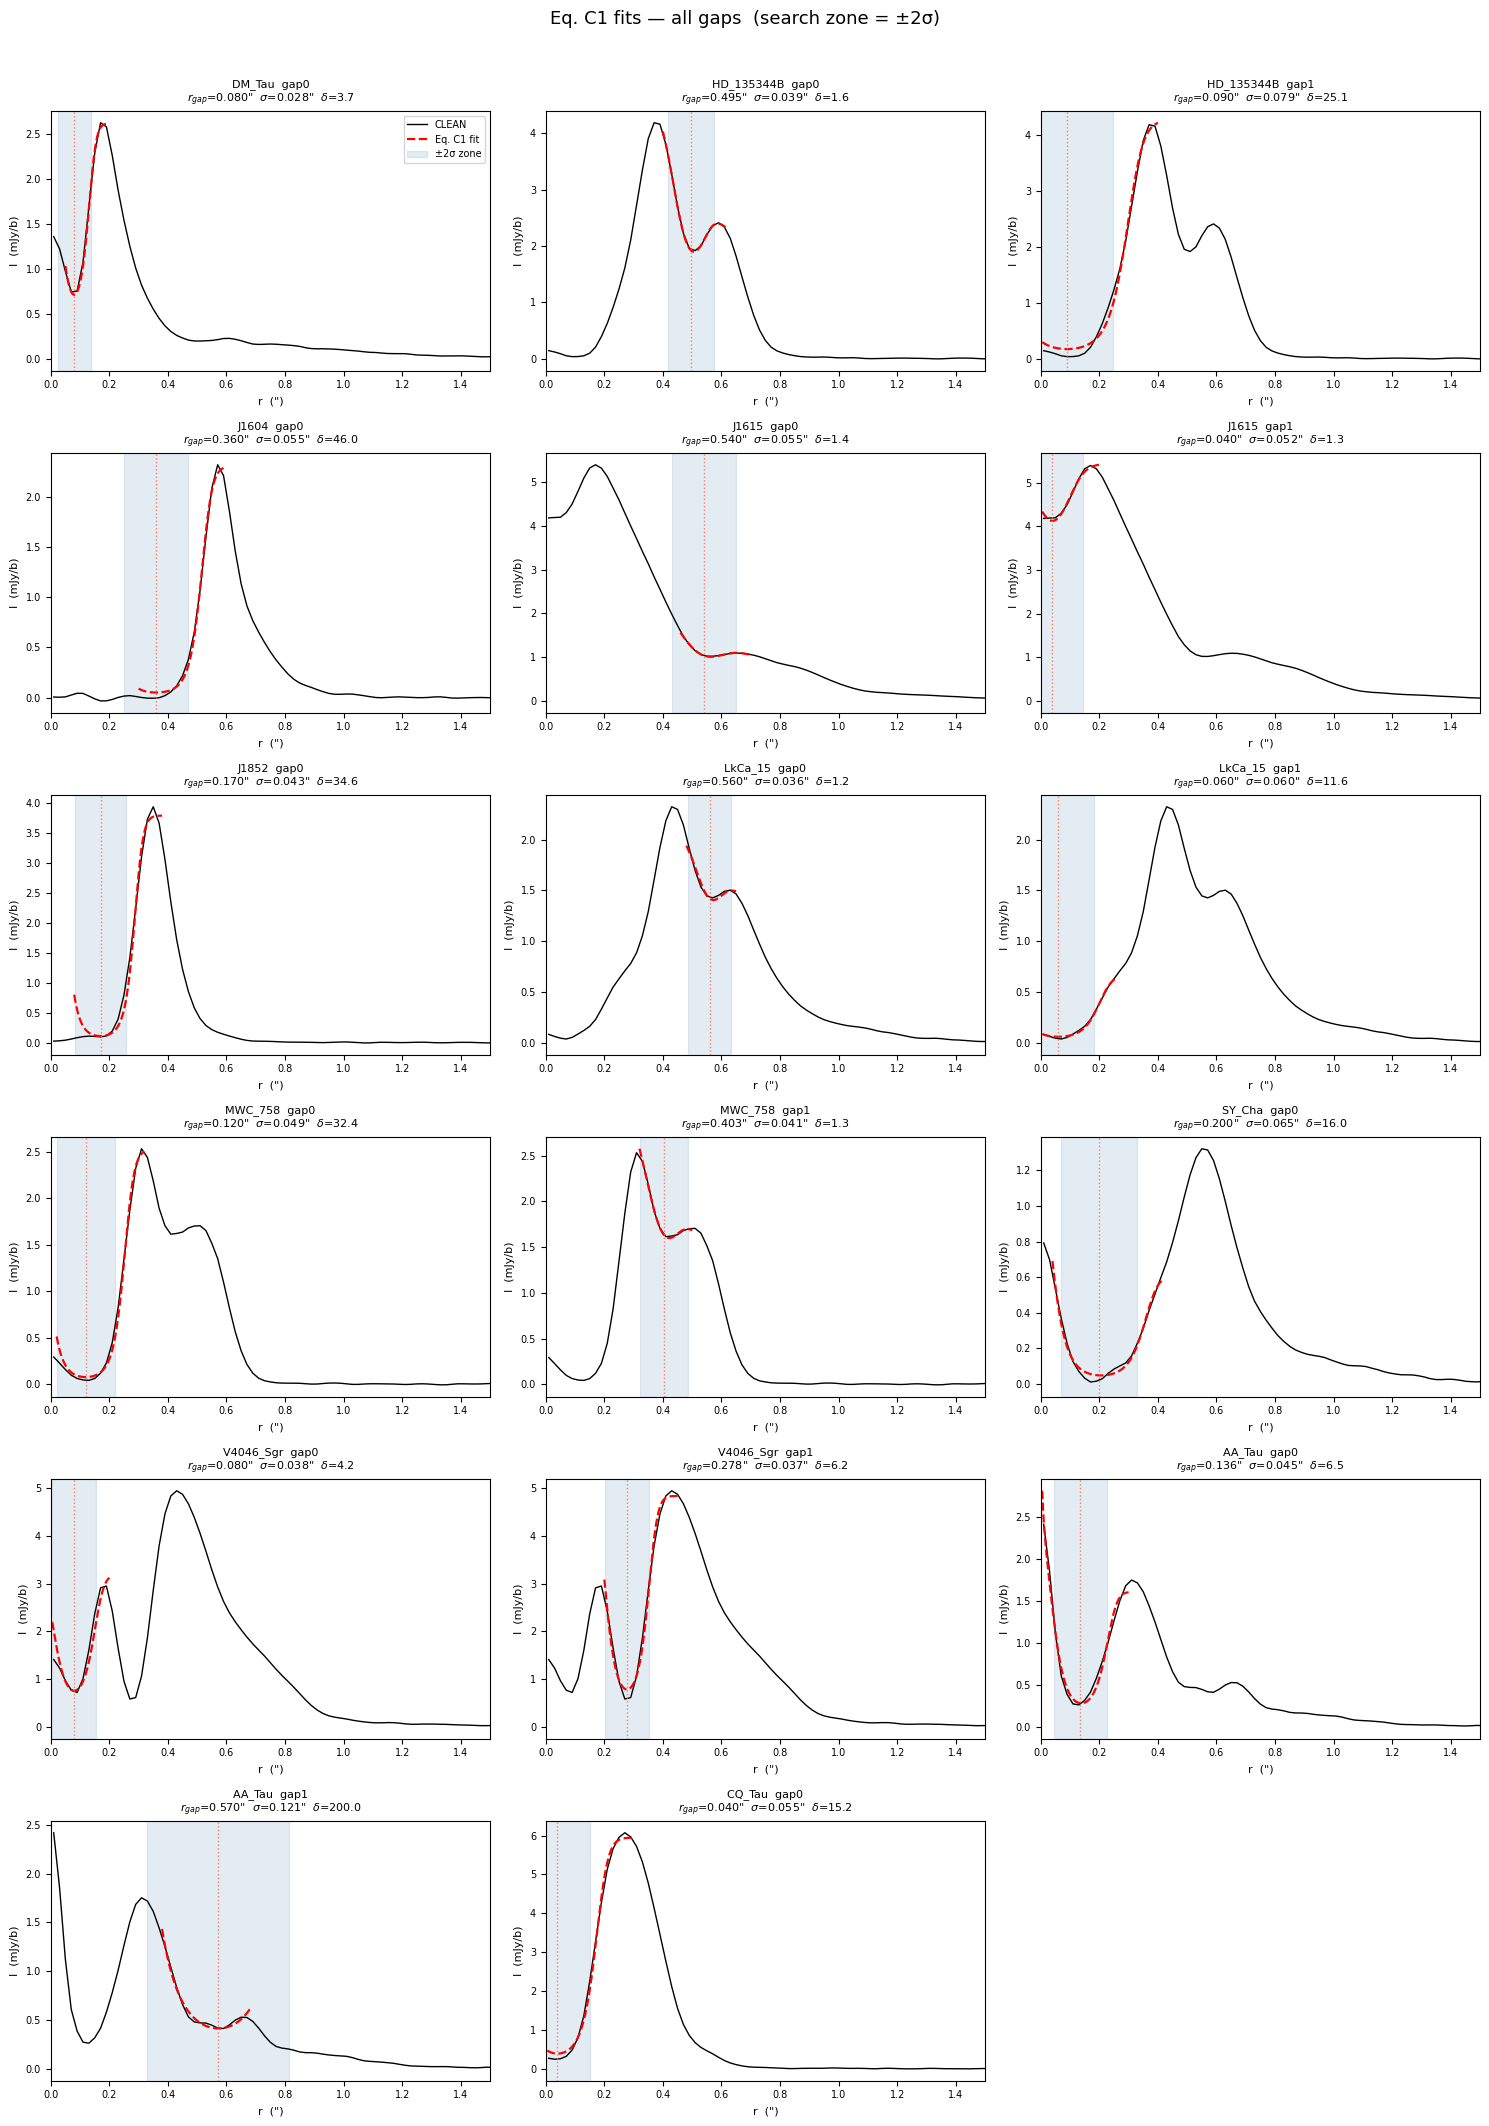

Saved  →  D:\CPD_MPIA\HPC_eqC1_gap\eqC1_all_fits.png
17 gap fits shown


In [10]:
# ── Summary: all gap fits ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_CSV = r'D:\CPD_MPIA\HPC_eqC1_gap\eqC1_fit_results.csv'
DATA_DIR    = r'D:\exoALMA_disk_data'
ZONE_NSIGMA = 2   # search zone = r_gap ± N×sigma_gap

df_res = pd.read_csv(RESULTS_CSV)

# keep only the latest fit per (disk, gap_ix) in case of duplicates
df_res = (df_res.sort_values('timestamp')
                .drop_duplicates(subset=['disk', 'gap_ix'], keep='last')
                .reset_index(drop=True))

n = len(df_res)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()

for i, row in df_res.iterrows():
    ax   = axes[i]
    disk = row['disk'];  gap_ix = int(row['gap_ix'])

    I0   = row['I0_fit'];   q    = row['q_fit']
    rgap = row['rgap_fit']; sgap = row['sgap_fit']; dgap = row['dgap_fit']
    r_min = row['r_min'];   r_max = row['r_max']

    # load CLEAN profile
    try:
        dat   = np.loadtxt(rf'{DATA_DIR}\{disk}\{disk}_CLEAN_profile_robust-05.txt',
                           comments='#')
        r_prof, I_prof = dat[:, 0], dat[:, 2]
    except Exception as e:
        ax.text(0.5, 0.5, f'profile missing\n{e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=7, color='red')
        ax.set_title(f'{disk}  gap{gap_ix}', fontsize=9); continue

    ax.plot(r_prof, I_prof, 'k-', lw=1, label='CLEAN')

    # Eq. C1 fit overlay
    r_model = np.linspace(r_min, r_max, 400)
    ax.plot(r_model, eqC1(r_model, I0, q, rgap, sgap, dgap),
            'r--', lw=1.6, label='Eq. C1 fit')

    # gap centre
    ax.axvline(rgap, color='tomato', ls=':', lw=1.0, alpha=0.8)

    # search zone = r_gap ± N×sigma_gap
    ax.axvspan(rgap - ZONE_NSIGMA * sgap, rgap + ZONE_NSIGMA * sgap,
               alpha=0.15, color='steelblue', label=f'±{ZONE_NSIGMA}σ zone')

    ax.set_xlim(0, min(float(r_prof.max()), 1.5))
    ax.set_xlabel('r  (")', fontsize=8)
    ax.set_ylabel('I  (mJy/b)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_title(f'{disk}  gap{gap_ix}\n'
                 f'$r_{{gap}}$={rgap:.3f}"  $\\sigma$={sgap:.3f}"  $\\delta$={dgap:.1f}',
                 fontsize=8)

axes[0].legend(fontsize=7, loc='upper right')

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Eq. C1 fits — all gaps  (search zone = ±{ZONE_NSIGMA}σ)',
             fontsize=13, y=1.01)
plt.tight_layout()

out_png = r'D:\CPD_MPIA\HPC_eqC1_gap\eqC1_all_fits.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved  →  {out_png}')
print(f'{n} gap fits shown')

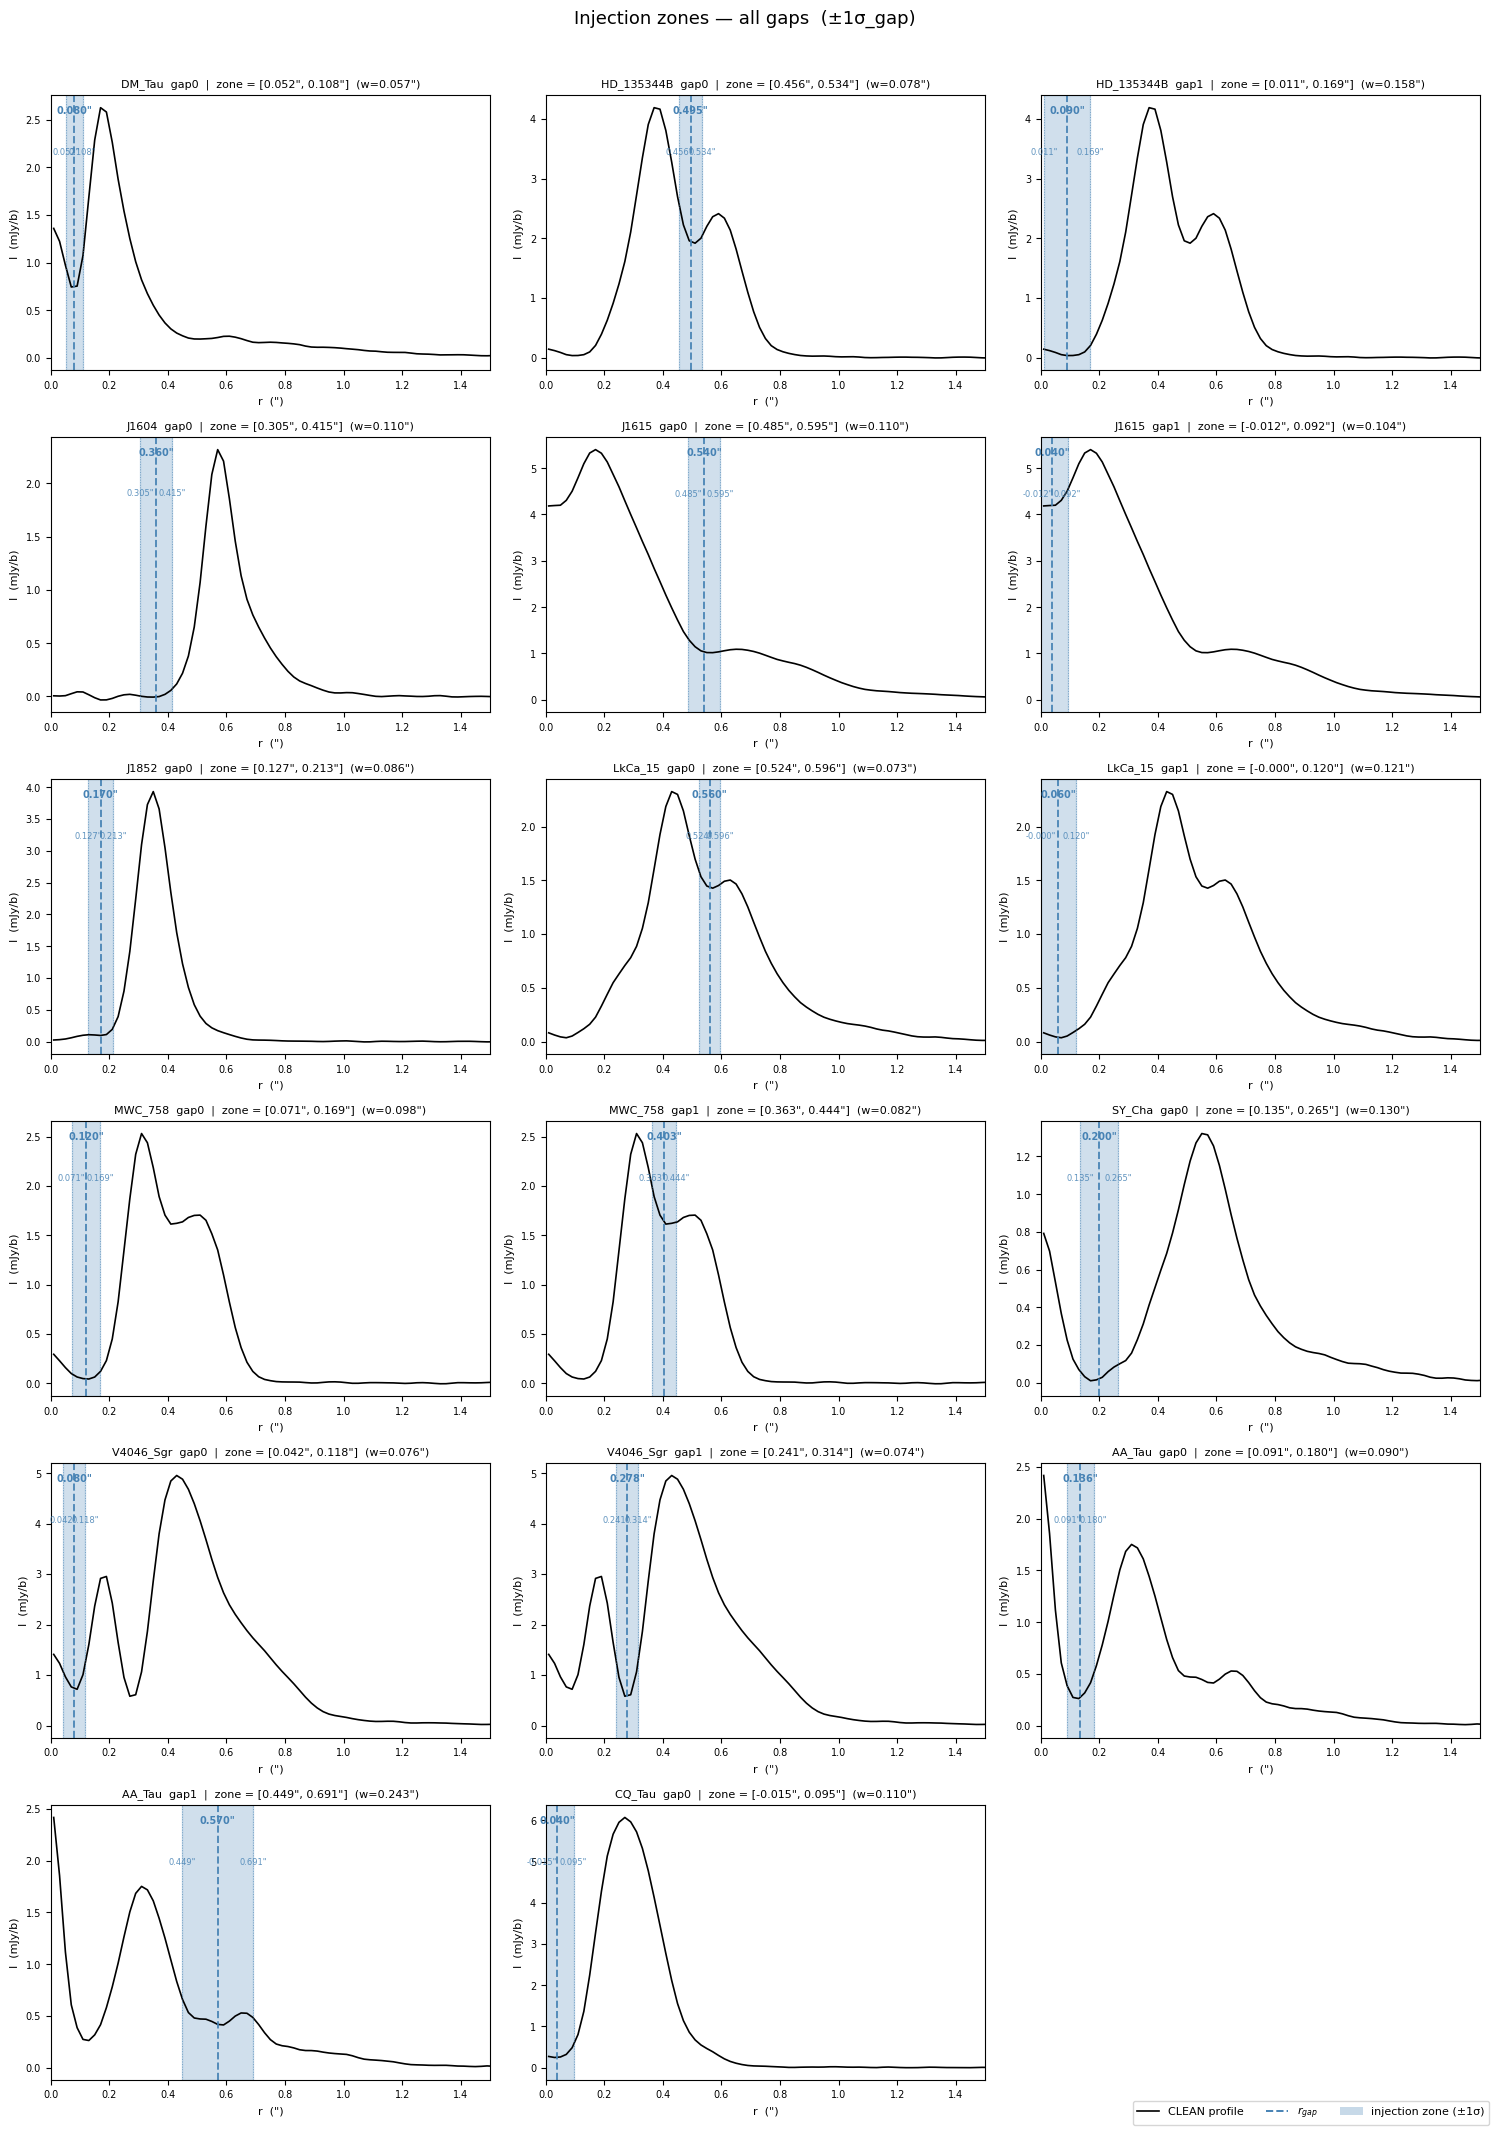

Saved  →  D:\CPD_MPIA\HPC_eqC1_gap\eqC1_injection_zones.png


In [12]:
# ── Summary: injection zones only (no fit curve) ─────────────────────────────
ZONE_NSIGMA = 1  # injection zone half-width = N × sigma_gap

df_res = pd.read_csv(RESULTS_CSV)
df_res = (df_res.sort_values('timestamp')
                .drop_duplicates(subset=['disk', 'gap_ix'], keep='last')
                .reset_index(drop=True))

n = len(df_res)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()

for i, row in df_res.iterrows():
    ax   = axes[i]
    disk = row['disk'];  gap_ix = int(row['gap_ix'])
    rgap = row['rgap_fit'];  sgap = row['sgap_fit']
    zone_lo = rgap - ZONE_NSIGMA * sgap
    zone_hi = rgap + ZONE_NSIGMA * sgap

    try:
        dat    = np.loadtxt(rf'{DATA_DIR}\{disk}\{disk}_CLEAN_profile_robust-05.txt',
                            comments='#')
        r_prof, I_prof = dat[:, 0], dat[:, 2]
    except Exception as e:
        ax.text(0.5, 0.5, f'profile missing\n{e}', ha='center', va='center',
                transform=ax.transAxes, fontsize=7, color='red')
        ax.set_title(f'{disk}  gap{gap_ix}', fontsize=9); continue

    # profile
    ax.plot(r_prof, I_prof, 'k-', lw=1.2)

    # injection zone shading
    ax.axvspan(zone_lo, zone_hi, alpha=0.25, color='steelblue')

    # gap centre
    ax.axvline(rgap, color='steelblue', lw=1.4, ls='--', alpha=0.9)

    # edge tick marks
    ylo, yhi = ax.get_ylim()
    for xv in [zone_lo, zone_hi]:
        ax.axvline(xv, color='steelblue', lw=0.7, ls=':', alpha=0.6)

    # labels: centre and edges
    ax.text(rgap, yhi * 0.96, f'{rgap:.3f}"',
            color='steelblue', fontsize=7, ha='center', va='top', fontweight='bold')
    ax.text(zone_lo, yhi * 0.80, f'{zone_lo:.3f}"',
            color='steelblue', fontsize=6, ha='center', va='top', alpha=0.85)
    ax.text(zone_hi, yhi * 0.80, f'{zone_hi:.3f}"',
            color='steelblue', fontsize=6, ha='center', va='top', alpha=0.85)

    ax.set_xlim(0, min(float(r_prof.max()), 1.5))
    ax.set_xlabel('r  (")', fontsize=8)
    ax.set_ylabel('I  (mJy/b)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_title(f'{disk}  gap{gap_ix}  |  '
                 f'zone = [{zone_lo:.3f}", {zone_hi:.3f}"]  '
                 f'(w={2*ZONE_NSIGMA*sgap:.3f}")',
                 fontsize=8)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0],[0], color='k',          lw=1.2,           label='CLEAN profile'),
    Line2D([0],[0], color='steelblue',  lw=1.4, ls='--',  label='$r_{gap}$'),
    Patch(facecolor='steelblue', alpha=0.3,                label=f'injection zone (±{ZONE_NSIGMA}σ)'),
], loc='lower right', fontsize=8, ncol=3, bbox_to_anchor=(1.0, 0.0))

plt.suptitle(f'Injection zones — all gaps  (±{ZONE_NSIGMA}σ_gap)', fontsize=13, y=1.01)
plt.tight_layout()

out_png2 = r'D:\CPD_MPIA\HPC_eqC1_gap\eqC1_injection_zones.png'
plt.savefig(out_png2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved  →  {out_png2}')